In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        59
           1       1.00      1.00      1.00        61

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

Confusion Matrix:
 [[59  0]
 [ 0 61]]


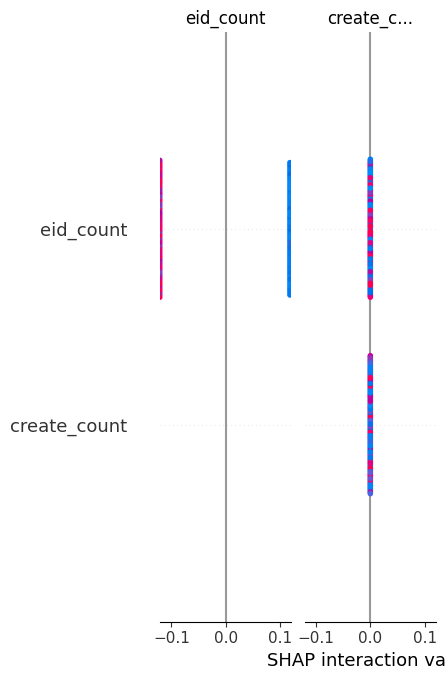

C:\Users\Anuj Raut\AppData\Local\Programs\Python\Python313\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
C:\Users\Anuj Raut\AppData\Local\Programs\Python\Python313\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
C:\Users\Anuj Raut\AppData\Local\Programs\Python\Python313\Lib\site-packages\lime\lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys 

LIME explanation saved as lime_explanation.html


In [8]:
# Step 1: Load mock logs
df = pd.read_csv("mock_ransomware_logs.csv")
X = df.drop('label', axis=1)
y = df['label']

# Step 2: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Train Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 4: Evaluate Model
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Step 5: Global Explanation with SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Handle binary classification formats
if isinstance(shap_values, list):
    # For older versions of SHAP (list of arrays for each class)
    shap.summary_plot(shap_values[1], X_test, feature_names=X.columns)
else:
    # For newer versions of SHAP (single numpy array)
    shap.summary_plot(shap_values, X_test, feature_names=X.columns)


# Step 6: Local Explanation with LIME
exp = lime_explainer.explain_instance(
    X_test.iloc[sample_index],   # use pandas row instead of .values
    model.predict_proba,
    num_features=5
)

# Explain one sample
#sample_index = 0
#exp = lime_explainer.explain_instance(X_test.values[sample_index], model.predict_proba, num_features=5)
#exp.show_in_notebook()

exp.save_to_file('lime_explanation.html')
print("LIME explanation saved as lime_explanation.html")